In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
import pickle
import os
import numpy as np
import pandas as pd
from copy import copy
from sklearn.preprocessing import StandardScaler

In [8]:
total_cv = 5
random_state = 7
no_of_active_features = 15
wandb_project = "RQ2RUN5"
optimization_metric = "average_precision_score"
# data_folder = "segment"
# data_folder = "shuttle"
# data_folder = "one_yeast"
# data_folder = "three_yeast"
data_folder = "thesis"

In [3]:
def precision_0(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def precision_1(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

def recall_0(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def recall_1(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

In [6]:
scorers_for_gridcv = {
    "accuracy_score": make_scorer(accuracy_score),
    "precision_0": make_scorer(precision_0, greater_is_better=True),
    "precision_1": make_scorer(precision_1, greater_is_better=True),
    "recall_0": make_scorer(recall_0, greater_is_better=True),
    "recall_1": make_scorer(recall_1, greater_is_better=True),
    "fbeta_score": make_scorer(fbeta_score, beta=0.5),
    "balanced_accuracy_score": make_scorer(balanced_accuracy_score),
    "average_precision_score": make_scorer(average_precision_score),
    "roc_auc": make_scorer(roc_auc_score),
}



In [4]:
def read_pickled_input_files(file_path: str):
    if file_path == None:
        return

    X_train_val = None
    y_train_val = None
    X_test = None
    y_test = None

    with open(os.path.join(file_path, "x_train_val_full.pickle"), "rb") as file:
        X_train_val = pickle.load(file)

    with open(os.path.join(file_path, "y_train_val_full.pickle"), "rb") as file:
        y_train_val = pickle.load(file)

    with open(os.path.join(file_path, "x_test_full.pickle"), "rb") as file:
        X_test = pickle.load(file)

    with open(os.path.join(file_path, "y_test_full.pickle"), "rb") as file:
        y_test = pickle.load(file)

    return X_train_val, X_test, y_train_val, y_test

X_train_val, X_test, y_train_val, y_test = read_pickled_input_files("./thesis/")


normalized_df = copy(X_train_val)
cd_first_quantile = np.quantile(normalized_df["characteristic_distance"], 0.25)
cd_third_quantile = np.quantile(normalized_df["characteristic_distance"], 0.75)
normalized_df["depth"] = np.log(normalized_df["depth"])
normalized_df["max_breadth"] = np.log(normalized_df["max_breadth"])
normalized_df["characteristic_distance"] = np.log(normalized_df["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile)
normalized_df["size"] = np.log(normalized_df["size"])
normalized_df["strongly_cc"] = np.log(normalized_df["strongly_cc"])

scaler = StandardScaler().set_output(transform="pandas")
scaled_X_train = scaler.fit_transform(normalized_df)
scaled_resampled_X_train, scaled_resampled_y_train = pd.DataFrame(scaled_X_train.to_numpy()), pd.Series(y_train_val.to_numpy())

In [14]:
from sklearn.linear_model import LogisticRegression
try:
    logit_grid = {
        "C": [_ for _ in range(1, 10, 1)],
        "fit_intercept": [True, False],
    }
    # logit_grid = {
    #     "penalty": ["l1", "l2", "elasticnet"],
    #     "dual": [True, False],
    #     "C": [_ for _ in range(1, 10, 1)],
    #     "fit_intercept": [True, False],
    #     "max_iter": [500],
    #     "solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"],
    #     "n_jobs": [-1],
    # }
    logit_model = LogisticRegression()

    clf = GridSearchCV(
        estimator=logit_model,
        cv=total_cv,
        refit=optimization_metric,
        param_grid=logit_grid,
        scoring=scorers_for_gridcv,
        verbose=0,
        n_jobs=-1,
    )

    logit_result = clf.fit(scaled_resampled_X_train, scaled_resampled_y_train)

except Exception as error:
    print(error)
    pass


In [10]:
pd.DataFrame.from_dict(logit_result.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_penalty,params,split0_test_accuracy_score,split1_test_accuracy_score,split2_test_accuracy_score,split3_test_accuracy_score,...,std_test_average_precision_score,rank_test_average_precision_score,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,0.147621,0.013865,0.049492,0.008627,l2,{'penalty': 'l2'},0.83826,0.837951,0.838106,0.838106,...,0.000062,1,0.5,0.499908,0.5,0.5,0.5,0.499982,0.000037,1


In [7]:
class CustomScore:
    def __init__(self, accuracy, precision_0, precision_1, recall_0, recall_1, balanced_accuracy, fbeta, avg_precision, roc_auc) -> None:
        self.accuracy = accuracy
        self.precision_0 = precision_0
        self.precision_1 = precision_1
        self.recall_0 = recall_0
        self.recall_1 = recall_1
        self.balanced_accuracy = balanced_accuracy
        self.fbeta = fbeta
        self.avg_precision = avg_precision
        self.roc_auc = roc_auc

    def get_default_metric(self) -> float:
        return self.avg_precision

In [15]:

def process_gridcv_results(cv_results, group, total_cv=5):
    
    for i in range(0, total_cv):
        acc_score = round(cv_results['mean_test_accuracy_score'][i], 2)
        prec_0 = round(cv_results['mean_test_precision_0'][i], 2)
        prec_1 = round(cv_results['mean_test_precision_1'][i], 2)
        rec_0 = round(cv_results['mean_test_recall_0'][i], 2)
        rec_1 = round(cv_results['mean_test_recall_1'][i], 2)
        fbeta = round(cv_results['mean_test_fbeta_score'][i], 2)
        ba_score = round(cv_results['mean_test_balanced_accuracy_score'][i], 2)
        avg_prec = round(cv_results['mean_test_average_precision_score'][i], 2)
        roc_auc = round(cv_results['mean_test_roc_auc'][i], 2)
        
        print({"accuracy": acc_score, "precision_0": prec_0, "precision_1": prec_1, "recall_0": rec_0, "recall_1": rec_1, "fbeta": fbeta, "balanced_accuracy": ba_score, "average_precision": avg_prec, "roc_auc": roc_auc})
        
    return

process_gridcv_results(logit_result.cv_results_, "dt")

{'accuracy': 0.84, 'precision_0': 0.84, 'precision_1': 0.0, 'recall_0': 1.0, 'recall_1': 0.0, 'fbeta': 0.0, 'balanced_accuracy': 0.5, 'average_precision': 0.16, 'roc_auc': 0.5}
{'accuracy': 0.57, 'precision_0': 0.86, 'precision_1': 0.19, 'recall_0': 0.58, 'recall_1': 0.51, 'fbeta': 0.22, 'balanced_accuracy': 0.55, 'average_precision': 0.18, 'roc_auc': 0.55}
{'accuracy': 0.84, 'precision_0': 0.84, 'precision_1': 0.0, 'recall_0': 1.0, 'recall_1': 0.0, 'fbeta': 0.0, 'balanced_accuracy': 0.5, 'average_precision': 0.16, 'roc_auc': 0.5}
{'accuracy': 0.57, 'precision_0': 0.86, 'precision_1': 0.19, 'recall_0': 0.58, 'recall_1': 0.51, 'fbeta': 0.22, 'balanced_accuracy': 0.55, 'average_precision': 0.18, 'roc_auc': 0.55}
{'accuracy': 0.84, 'precision_0': 0.84, 'precision_1': 0.0, 'recall_0': 1.0, 'recall_1': 0.0, 'fbeta': 0.0, 'balanced_accuracy': 0.5, 'average_precision': 0.16, 'roc_auc': 0.5}


In [2]:
import pandas as pd

C:\Users\istiyak\AppData\Local\Temp\ipykernel_11148\4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# segment0.csv
# shuttle-c0-vs-c4.csv
# yeast1.csv
# yeast3.csv
import pandas as pd 

folder = "./segment"
df = pd.read_csv('./all_csv/segment0.csv')
list(df.columns)

['Region-centroid-col',
 'Region-centroid-row',
 'Region-pixel-count',
 'Short-line-density-5',
 'Short-line-density-2',
 'Vedge-mean',
 'Vegde-sd',
 'Hedge-mean',
 'Hedge-sd',
 'Intensity-mean',
 'Rawred-mean',
 'Rawblue-mean',
 'Rawgreen-mean',
 'Exred-mean',
 'Exblue-mean',
 'Exgreen-mean',
 'Value-mean',
 'Saturatoin-mean',
 'Hue-mean',
 'Class']

In [3]:
df['Class'].replace('negative', 0, inplace=True)
df['Class'].replace('positive', 1, inplace=True)

C:\Users\siddiquee\AppData\Local\Temp\ipykernel_3740\1292568918.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Class'].replace('negative', 0, inplace=True)
C:\Users\siddiquee\AppData\Local\Temp\ipykernel_3740\1292568918.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [4]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, RepeatedKFold

X = df.iloc[:, 0:len(list(df.columns))-1]
Y = df.iloc[:, len(list(df.columns))-1]
# split data into train and test sets
seed = 7
test_size = 0.10
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=test_size, stratify=df['Class'], random_state=seed)
X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape

((2077, 19), (231, 19), (2077,), (231,))

In [5]:
import pickle

with open(folder + "/x_train_val.pickle", "wb") as file:
    pickle.dump(X_train_val, file)

with open(folder + "/y_train_val.pickle", "wb") as file:
    pickle.dump(y_train_val, file)

with open(folder + "/x_test.pickle", "wb") as file:
    pickle.dump(X_test, file)

with open(folder + "/y_test.pickle", "wb") as file:
    pickle.dump(y_test, file)        

# call the nested loop to get all the trained models
print(X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape)


(2077, 19) (231, 19) (2077,) (231,)


In [5]:
from copy import copy
import pickle
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

original_column_order= list(df.columns)[0:len(list(df.columns))-1]

normalized_df = copy(X_train_val)

scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('scale', scaler, list(X_train_val.columns))
], verbose_feature_names_out=False)
    
scaled_X_train_val = preprocessor.fit_transform(normalized_df)
scaled_X_test = preprocessor.transform(X_test)

transformed_columns = list(preprocessor.get_feature_names_out())

# transformed_columns[transformed_columns.index('scale__characteristic_distance')] = 'log_norm__characteristic_distance'
# original_column_order[original_column_order.index('scale__characteristic_distance')] = 'log_norm__characteristic_distance'

scaled_X_train_val_df = pd.DataFrame(scaled_X_train_val, columns=transformed_columns)
scaled_X_test_df = pd.DataFrame(scaled_X_test, columns=transformed_columns)

scaled_X_train_val_df =  scaled_X_train_val_df[original_column_order]
scaled_X_test_df =  scaled_X_test_df[original_column_order]

# Feature Selection

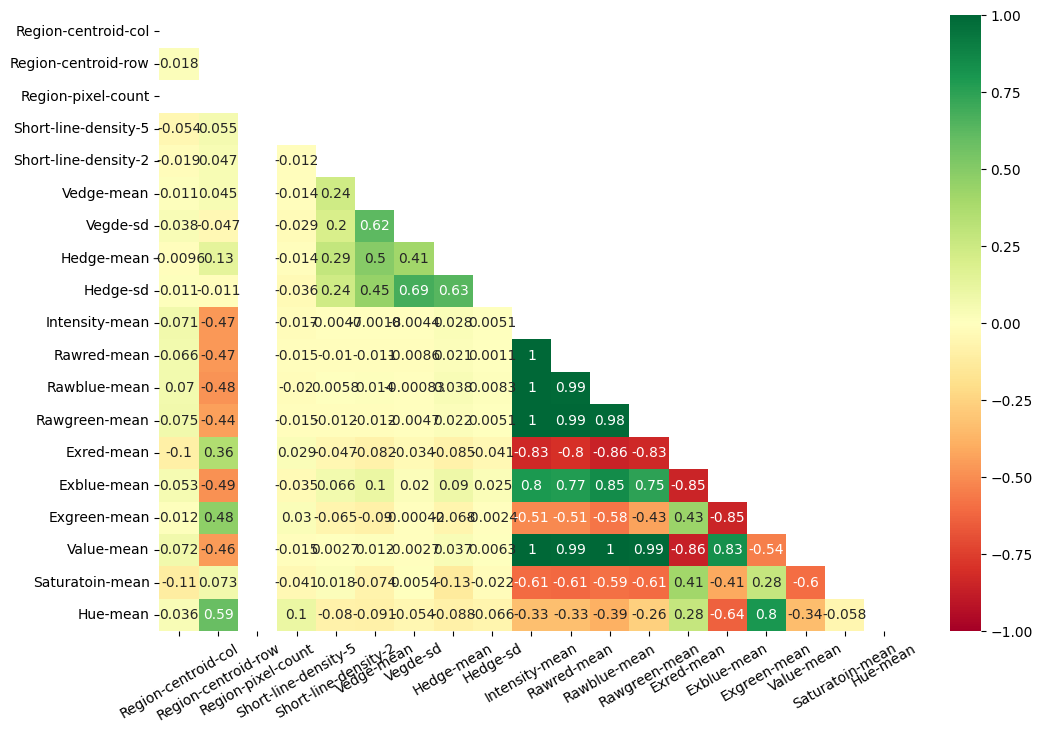

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(scaled_X_train_val_df.corr(), dtype=bool))
sns.heatmap(scaled_X_train_val_df.corr(method='pearson', numeric_only = True), annot=True, mask=mask, vmin=-1, vmax=1, cmap ='RdYlGn')
plt.xticks(rotation=30) 
plt.savefig(folder+'/segment_pearson_all_features.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

In [19]:
# load statmodels functions
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the vif for all given features
def compute_vif(df, considered_features):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

considered_features = list(scaled_X_train_val_df.columns)
# considered_features.remove('A8')
# considered_features.remove('A9')
# considered_features.remove('A7')
considered_features.remove('Intensity-mean')
considered_features.remove('Rawgreen-mean')
considered_features.remove('Rawblue-mean')
considered_features.remove('Exblue-mean')
considered_features.remove('Value-mean')

# considered_features.remove('Rawred-mean')
# considered_features.remove('Exred-mean')
# considered_features.remove('Exgreen-mean')

# considered_features.remove('density')
# considered_features.remove('structural_heterogeneity')
# considered_features.remove('size')
# considered_features.remove('size_of_scc')

# compute vif 
compute_vif(scaled_X_train_val_df, considered_features).sort_values('VIF', ascending=False)

C:\Users\siddiquee\AppData\Local\Temp\ipykernel_3400\2661132503.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['intercept'] = 1
C:\Users\siddiquee\AppData\Roaming\Python\Python312\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variable,VIF
9,Rawred-mean,4.967990
13,Hue-mean,4.919774
11,Exgreen-mean,4.337732
10,Exred-mean,3.034111
8,Hedge-sd,2.765975
6,Vegde-sd,2.639435
12,Saturatoin-mean,2.412829
7,Hedge-mean,2.182948
1,Region-centroid-row,2.023798
5,Vedge-mean,1.975928


In [24]:
considered_features

['Region-centroid-col',
 'Region-centroid-row',
 'Region-pixel-count',
 'Short-line-density-5',
 'Short-line-density-2',
 'Vedge-mean',
 'Vegde-sd',
 'Hedge-mean',
 'Hedge-sd',
 'Rawgreen-mean',
 'Saturatoin-mean',
 'Hue-mean']

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso, LogisticRegression

scaler = StandardScaler()
scaler.fit(scaled_X_train_val_df[considered_features])
sel_ = SelectFromModel(LogisticRegression(C=0.5, penalty='l1', solver='liblinear', random_state=10))
sel_.fit(scaler.transform(scaled_X_train_val_df[considered_features]), y_train_val)
removed_feats = scaled_X_train_val_df[considered_features].columns[(sel_.estimator_.coef_ == 0).ravel().tolist()]
removed_feats

Index(['Region-pixel-count', 'Vegde-sd'], dtype='object')

In [26]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rfe_selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=len(scaled_X_train_val_df[considered_features].columns)-1, step=1, verbose=5)
rfe_selector.fit(scaled_X_train_val_df[considered_features], y_train_val)
rfe_support = rfe_selector.get_support()
rfe_feature = scaled_X_train_val_df[considered_features].loc[:,rfe_support].columns.tolist()
print(str(len(rfe_feature)), 'selected features')
print(rfe_feature)

Fitting estimator with 12 features.
11 selected features
['Region-centroid-col', 'Region-centroid-row', 'Short-line-density-5', 'Short-line-density-2', 'Vedge-mean', 'Vegde-sd', 'Hedge-mean', 'Hedge-sd', 'Rawgreen-mean', 'Saturatoin-mean', 'Hue-mean']


c:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
270 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1194, in fit
    

<Axes: >

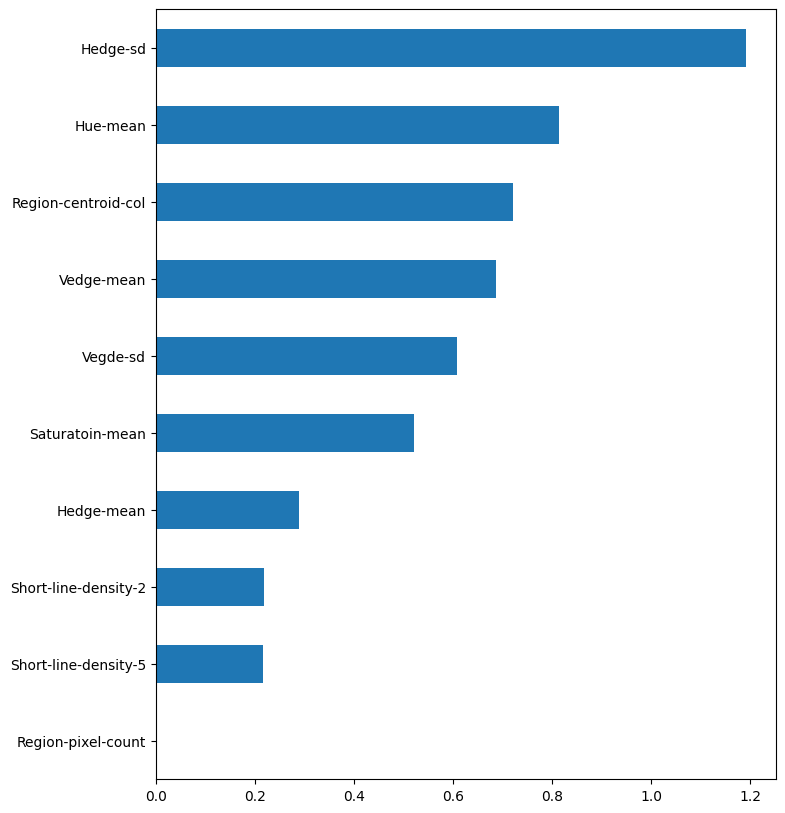

In [27]:
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib
import pandas as pd 

clf_grid = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "C": [_ for _ in range(1, 10, 1)],
    "dual": [True, False],
}

model = LogisticRegression()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=clf_grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train_val_df[considered_features].values, y_train_val.values)
coefficients = np.abs(clf.best_estimator_.coef_)

coef = pd.Series(coefficients[0], index = scaled_X_train_val_df[considered_features].columns)
coef = pd.concat([coef.sort_values().head(10)])


matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
coef.plot(kind = "barh")
# plt.title("Coefficients in the Logistic Model")
# plt.savefig(prefix + 'logistic_feature.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

c:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.655e+01, tolerance: 2.538e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

<Axes: >

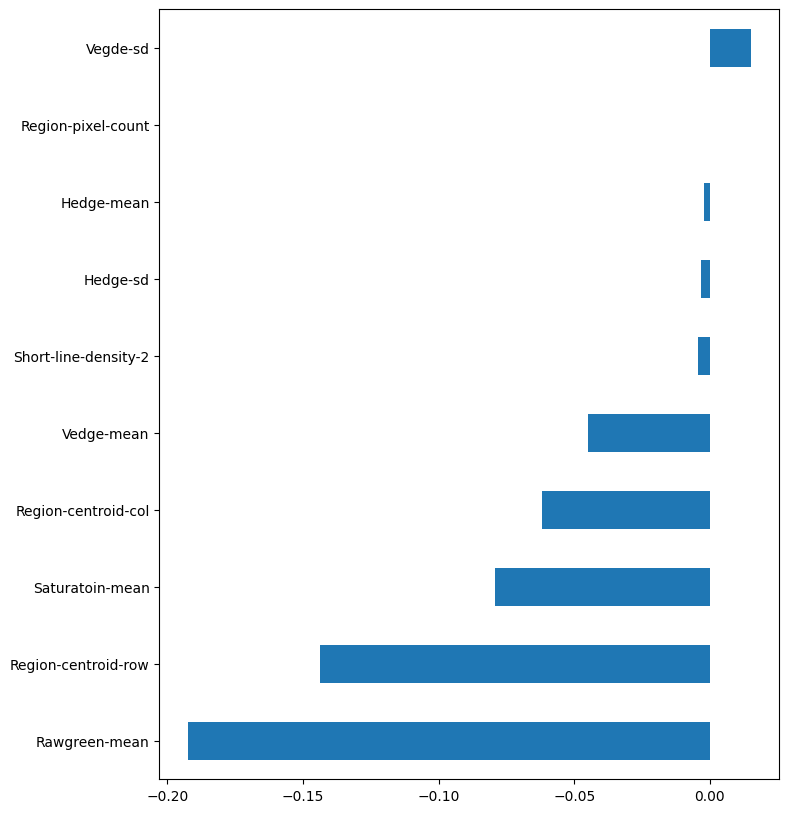

In [28]:
from sklearn.linear_model import ElasticNet
import matplotlib
import matplotlib.pyplot as plt
from numpy import arange

grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0],
    'l1_ratio': arange(0, 1, 0.1)
}

model = ElasticNet()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train_val_df[considered_features], y_train_val)

coef = pd.Series(clf.best_estimator_.coef_, index = scaled_X_train_val_df[considered_features].columns)
imp_coef = pd.concat([coef.sort_values().head(10)])

matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
# plt.title("Coefficients in the Elastic Net Model")
# plt.savefig(prefix + 'elastic_feature.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

In [29]:
import numpy as np
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# define random forest classifier
rfc = RandomForestClassifier()
boruta_selector = BorutaPy(rfc, n_estimators='auto', verbose=2, random_state=1)
boruta_selector.fit(np.array(scaled_X_train_val_df[considered_features]), np.array(y_train_val)) 

selected_rf_features = pd.DataFrame({'Feature':list(scaled_X_train_val_df[considered_features].columns),
                                      'Ranking':boruta_selector.ranking_})
selected_rf_features.sort_values(by='Ranking')

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	9
Tentative: 	0
Rejected: 	3


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	9
Tentative: 	0
Rejected: 	3


,Feature,Ranking
0,Region-centroid-col,1
1,Region-centroid-row,1
5,Vedge-mean,1
6,Vegde-sd,1
7,Hedge-mean,1
8,Hedge-sd,1
9,Rawgreen-mean,1
10,Saturatoin-mean,1
11,Hue-mean,1
3,Short-line-density-5,2


In [3]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['figure.dpi'] = 100

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(X_train_val.corr(), dtype=bool))
ax = sns.heatmap(X_train_val.corr(method='pearson', numeric_only = True), annot=True, mask=mask, vmin=-1, vmax=1, cmap ='RdYlGn')
# plt.savefig("appendix-yeast1.eps", format='eps')

NameError: name 'X_train_val' is not defined

<Figure size 700x500 with 0 Axes>

In [9]:
# load statmodels functions
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the vif for all given features
def compute_vif(df, considered_features):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

considered_features = list(X_train_val.columns)
# considered_features.remove('A8')
# considered_features.remove('A9')
# considered_features.remove('A7')
considered_features.remove('Intensity-mean')
considered_features.remove('Rawgreen-mean')
# considered_features.remove('Exblue-mean')
considered_features.remove('Rawred-mean')
considered_features.remove('Rawblue-mean')
# compute vif 
compute_vif(X_train_val, considered_features).sort_values('VIF', ascending=False)

C:\Users\istiyak\AppData\Local\Temp\ipykernel_944\877936437.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['intercept'] = 1
C:\Users\istiyak\AppData\Roaming\Python\Python311\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


,Variable,VIF
10,Exblue-mean,2.001600e+14
9,Exred-mean,7.092283e+13
11,Exgreen-mean,7.092283e+13
12,Value-mean,7.332467e+00
14,Hue-mean,4.853281e+00
8,Hedge-sd,2.955865e+00
6,Vegde-sd,2.682939e+00
13,Saturatoin-mean,2.471774e+00
7,Hedge-mean,2.432761e+00
5,Vedge-mean,2.089921e+00


In [48]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
    --------------------------------------- 0.0/1.3 MB 330.3 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.3 MB 563.7 kB/s eta 0:00:03
   ----------- ---------------------------- 0.4/1.3 MB 2.3 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.3 MB 3.9 MB/s eta 0:00:01
   ----------------------------------- ---- 1.2/1.3 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.7 MB/s eta 0:00:00


In [47]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rfe_selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=12, step=1, verbose=5)
rfe_selector.fit(X_train_val, y_train_val)
rfe_support = rfe_selector.get_support()
rfe_feature = X_train_val.loc[:,rfe_support].columns.tolist()
print(str(len(rfe_feature)), 'selected features')
print(rfe_feature)

Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
12 selected features
['Region-centroid-col', 'Region-centroid-row', 'Intensity-mean', 'Rawred-mean', 'Rawblue-mean', 'Rawgreen-mean', 'Exred-mean', 'Exblue-mean', 'Exgreen-mean', 'Value-mean', 'Saturatoin-mean', 'Hue-mean']


In [ ]:
rfe_selector.ranking_

array([3, 1, 1, 1, 2, 1, 1, 1, 1, 1])

In [ ]:
feature_selection_df = pd.DataFrame({'Feature':feature_name, 'Pearson':cor_support, 'Chi-2':chi_support, 'RFE':rfe_support, 'Logistics':embeded_lr_support,
                                    'Random Forest':embeded_rf_support, 'LightGBM':embeded_lgb_support})
# count the selected times for each feature
feature_selection_df['Total'] = np.sum(feature_selection_df, axis=1)
# display the top 100
feature_selection_df = feature_selection_df.sort_values(['Total','Feature'] , ascending=False)
feature_selection_df.index = range(1, len(feature_selection_df)+1)
feature_selection_df.head(num_feats)

In [ ]:
considered_features = ['max_breadth', 'density', 'virality', 'depth', 'structural_heterogeneity', 'characteristic_distance', 'size_of_scc', 'layer_ratio']

In [58]:
y_train_val.dtype

dtype('O')

In [5]:
import lightgbm as lgb

gbm = lgb.LGBMRegressor()
gbm.fit(X_train_val, y_train_val.astype('int32'))
gbm.booster_.feature_importance()

# importance of each attribute
fea_imp_ = pd.DataFrame({'cols':X_train_val.columns, 'feature_imp':gbm.feature_importances_})
fea_imp_.loc[fea_imp_.feature_imp > 0].sort_values(by=['feature_imp'], ascending = False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 9
[LightGBM] [Info] Start training from score 0.068211
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,cols,feature_imp
6,A7,105
0,A1,78
2,A3,15
5,A6,13
1,A2,8
4,A5,8
3,A4,4
7,A8,3
8,A9,2


In [ ]:
'Intensity-mean'
'Rawgreen-mean'
'Exblue-mean'
'Rawred-mean'
'Rawblue-mean'

# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
 
# To scale data
scaled_X_train = scaler.fit_transform(X_train)

In [ ]:
features = load_diabetes()['feature_names']
pipeline = Pipeline([
                     ('scaler',StandardScaler()),
                     ('model',Lasso())
])
search = GridSearchCV(pipeline,
                      {'model__alpha':np.arange(0.1,10,0.1)},
                      cv = 5, scoring="neg_mean_squared_error",verbose=3
                      )
search.fit(X_train,y_train)
search.best_params_
coefficients = search.best_estimator_.named_steps['model'].coef_

importance = np.abs(coefficients)
np.array(features)[importance > 0]
np.array(features)[importance == 0]

In [ ]:
xgb_grid = {
    
        "learning_rate": [0.001, 0.005, 0.01],
            "n_estimators": [8, 16, 24],
            "num_leaves": [6, 8, 12],  # large num_leaves helps improve accuracy but might lead to over-fitting
            "boosting_type": ["gbdt", "dart"],  # for better accuracy -> try dart
            
            "subsample": [0.7, 0.75],
            "reg_alpha": [1, 1.2],
            "reg_lambda": [1, 1.2, 1.4],
}

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(xgb_grid)
len(pg)

648

In [ ]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.4.0-1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
  Using cached scipy-1.12.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.4 MB)
  Using cached threadpoolctl-3.2.0-py3-none-any.whl (15 kB)
  Using cached numpy-1.26.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)


In [ ]:
dt_grid = {
            "criterion": ["gini", "entropy", "log_loss"],
            "splitter": ["best", "random"],
            "max_depth": [_ for _ in range(1, 5, 1)],
            "min_samples_split": [_ for _ in range(1, 5, 1)],
            "min_samples_leaf": [_ for _ in range(1, 10, 1)],
        }

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(dt_grid)
len(pg)

864

In [ ]:
import pickle
file_path = './image'
with open(file_path + "/x_train_val.pickle", "rb") as file:
    X_train_val = pickle.load(file)
    
X_train_val.shape

(32305, 8)

In [ ]:
X_train_val

,depth,max_breadth,virality,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
76742,2.0,15.0,0.076316,20.0,0.050000,1.333333,1.807954,1.444840
65438,1.0,4.0,0.250000,4.0,0.250000,1.000000,1.154701,3.497332
77936,3.0,12.0,0.104575,18.0,0.055556,1.416667,1.578401,1.031867
62375,1.0,3.0,0.333333,3.0,0.333333,1.000000,1.060660,2.466303
67452,1.0,5.0,0.200000,5.0,0.200000,1.000000,1.250000,4.445556
...,...,...,...,...,...,...,...,...
53331,1.0,2.0,0.500000,2.0,0.500000,1.000000,1.000000,1.439579
2282,2.0,2.0,0.666667,3.0,0.333333,1.500000,1.060660,1.819785
64675,1.0,4.0,0.250000,4.0,0.250000,1.000000,1.154701,3.497332
51667,1.0,2.0,0.500000,2.0,0.500000,1.000000,1.000000,1.439579
